<a href="https://colab.research.google.com/github/jcjcjjc-kekeodt/CPE-311/blob/main/Midterm_Quiz_2__Debolgado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Overview**<br>
Perform data analysis over the RT-IoT2022 Dataset using Pandas.

#**Submission Requirements**


1.   Submit the PDF file of the data analysis using pandas for the RT-IoT2022 Dataset.
2.   Submit the link to your Python notebook through the comments for point of clarification.



#**Discussion & Procedures**
**A. Dataset Information**


*   The RT-IoT2022, a proprietary dataset encompasses both normal and adversarial network behaviors, providing a general representation of real-world scenarios.

*   Incorporating data from IoT devices such as ThingSpeak-LED, Wipro-Bulb, and MQTT-Temp, as well as simulated attack scenarios involving Brute-Force SSH attacks, DDoS attacks using Hping and Slowloris, and Nmap patterns, RT-IoT2022 offers a detailed perspective on the complex nature of network traffic. The bidirectional attributes of network traffic are meticulously captured using the Zeek network monitoring tool and the Flowmeter plugin.

*   Infrastructure consists of two parts, namely IoT victim devices and IoT attacker devices, both connected through a router. We collect the network traffic through a router using Wireshark, which is an open-source monitoring tool for network traffic that helps extract traces and convert them into a PCAP file.
*   The attacking infrastructure includes 50 machines, and the victim organization has 5 departments and includes 420 machines and 30 servers. The dataset includes the captures network traffic and system logs of each machine, along with 80 features extracted from the captured traffic.


*   It includes 9 different attack scenarios: DOS_SYN_Hping,, ARP_poisioning, NMAP_UDP_SCAN,
NMAP_XMAS_TREE_SCAN, NMAP_OS_DETECTION, NMAP_TCP_scan, DDOS_Slowloris, Metasploit_Brute_Force_SSH, NMAP_FIN_SCAN and 3 normal pattern MQTT, Thing_speak and Wipro_bulb_Dataset.






**B. Procedure** <br>
For this quiz, you must build an end-to-end data analysis notebook following the ETL pipeline.



1.   On a separate document, create a table with 3 columns. Column 1: Phase, Column 2: Activity, and Column 3: Code and Output.


*   Phase will only have 3 major rows: Extract, Transform, Load
*   Activity will list down all the activities you performed per phase.
*   Code and output will correspond to the activity.


2.   Extract the provided dataset using FLAT FILE. You get extra points for loading it through Kaggle API.


import kagglehub<br>

Download latest version<br>

path = kagglehub.dataset_download("supplejade/rt-iot2022real-time-internet-of-things")<br>
print("Path to dataset files:", path)<br>

3.   Transform the dataset. List down all activities included in the transformation.
4.   Show the transformed dataset.
5.   Load the dataset and perform statistical analysis and visualization. List down all activities included in the "load" phase.






In [1]:
import kagglehub

path = kagglehub.dataset_download("supplejade/rt-iot2022real-time-internet-of-things")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'rt-iot2022real-time-internet-of-things' dataset.
Path to dataset files: /kaggle/input/rt-iot2022real-time-internet-of-things


In [8]:
import pandas as pd

file_path = path + "/RT_IOT2022.csv"
df = pd.read_csv(file_path)
print(df.head())


   no  id.orig_p  id.resp_p proto service  flow_duration  fwd_pkts_tot  \
0   0      38667       1883   tcp    mqtt      32.011598             9   
1   1      51143       1883   tcp    mqtt      31.883584             9   
2   2      44761       1883   tcp    mqtt      32.124053             9   
3   3      60893       1883   tcp    mqtt      31.961063             9   
4   4      51087       1883   tcp    mqtt      31.902362             9   

   bwd_pkts_tot  fwd_data_pkts_tot  bwd_data_pkts_tot  ...  active.std  \
0             5                  3                  3  ...         0.0   
1             5                  3                  3  ...         0.0   
2             5                  3                  3  ...         0.0   
3             5                  3                  3  ...         0.0   
4             5                  3                  3  ...         0.0   

       idle.min      idle.max      idle.tot      idle.avg  idle.std  \
0  2.972918e+07  2.972918e+07  2.972918

In [38]:
from google.colab import files
uploaded = files.upload()


Saving RT_IOT2022.csv to RT_IOT2022.csv


In [39]:
data = pd.read_csv("RT_IOT2022.csv")


In [41]:
import os
print(os.getcwd())


/content


In [11]:
df.isnull().sum()
df = df.dropna()



In [29]:
import pandas as pd
print(df.columns.tolist())


['no', 'id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_iat.min', 'fwd_iat.max', 'fwd_iat.tot', 'fwd

In [34]:
df.columns = df.columns.str.strip().str.lower()

print(df.columns.tolist())



['no', 'id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_fin_flag_count', 'flow_syn_flag_count', 'flow_rst_flag_count', 'fwd_psh_flag_count', 'bwd_psh_flag_count', 'flow_ack_flag_count', 'fwd_urg_flag_count', 'bwd_urg_flag_count', 'flow_cwr_flag_count', 'flow_ece_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_iat.min', 'fwd_iat.max', 'fwd_iat.tot', 'fwd

In [36]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['attack_type'] = encoder.fit_transform(df['attack_type'])

print(df[['attack_type']].head())

label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print(label_mapping)




   attack_type
0            3
1            3
2            3
3            3
4            3
{'ARP_poisioning': np.int64(0), 'DDOS_Slowloris': np.int64(1), 'DOS_SYN_Hping': np.int64(2), 'MQTT_Publish': np.int64(3), 'Metasploit_Brute_Force_SSH': np.int64(4), 'NMAP_FIN_SCAN': np.int64(5), 'NMAP_OS_DETECTION': np.int64(6), 'NMAP_TCP_scan': np.int64(7), 'NMAP_UDP_SCAN': np.int64(8), 'NMAP_XMAS_TREE_SCAN': np.int64(9), 'Thing_Speak': np.int64(10), 'Wipro_bulb': np.int64(11)}


Transformed Dataset Sample
   no  id.orig_p  id.resp_p proto service  flow_duration  fwd_pkts_tot  \
0   0      38667       1883   tcp    mqtt      32.011598             9   
1   1      51143       1883   tcp    mqtt      31.883584             9   
2   2      44761       1883   tcp    mqtt      32.124053             9   
3   3      60893       1883   tcp    mqtt      31.961063             9   
4   4      51087       1883   tcp    mqtt      31.902362             9   

   bwd_pkts_tot  fwd_data_pkts_tot  bwd_data_pkts_tot  ...      idle.min  \
0             5                  3                  3  ...  2.972918e+07   
1             5                  3                  3  ...  2.985528e+07   
2             5                  3                  3  ...  2.984215e+07   
3             5                  3                  3  ...  2.991377e+07   
4             5                  3                  3  ...  2.981470e+07   

       idle.max      idle.tot      idle.avg  idle.std  fwd_init_window_

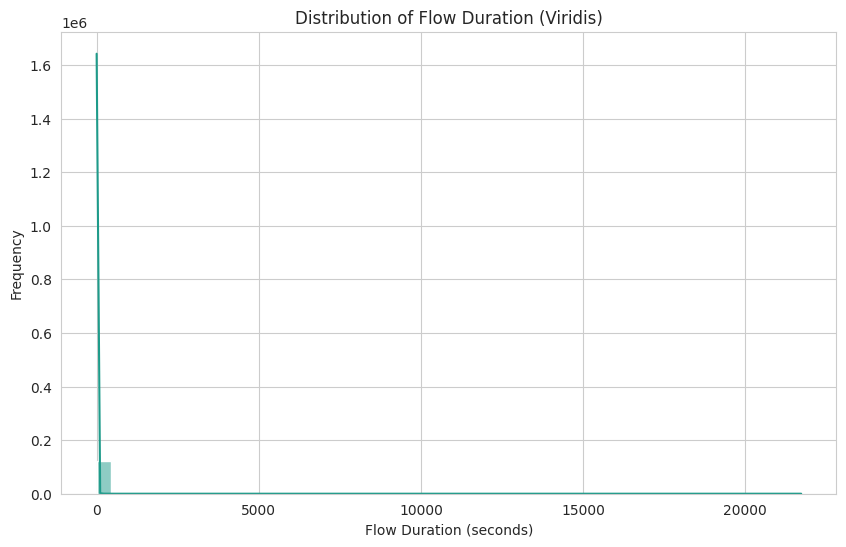

/tmp/ipykernel_378/3175095386.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label_encoded', y='fwd_pkts_per_sec', data=df, palette="viridis")


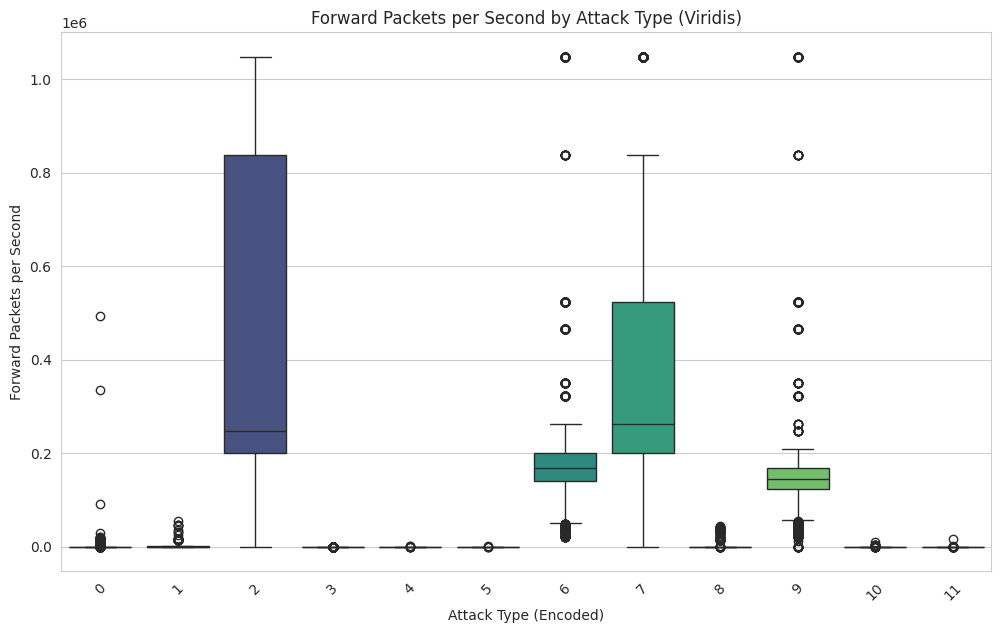

/tmp/ipykernel_378/3175095386.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label_encoded', y='fwd_pkts_per_sec', data=df, palette="plasma")


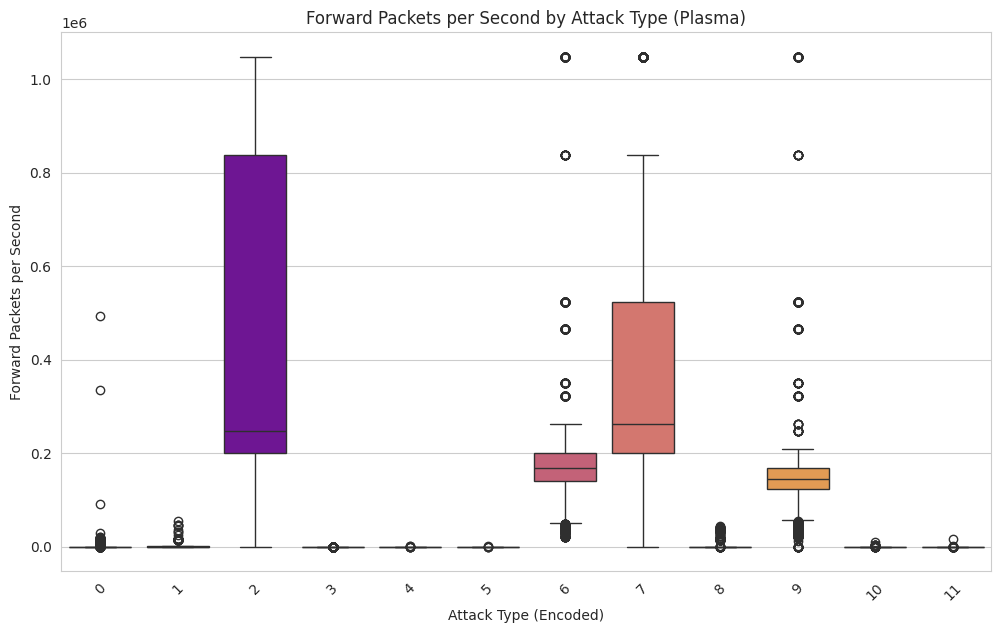

/tmp/ipykernel_378/3175095386.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label_encoded', y='fwd_pkts_per_sec', data=df, palette="Blues")


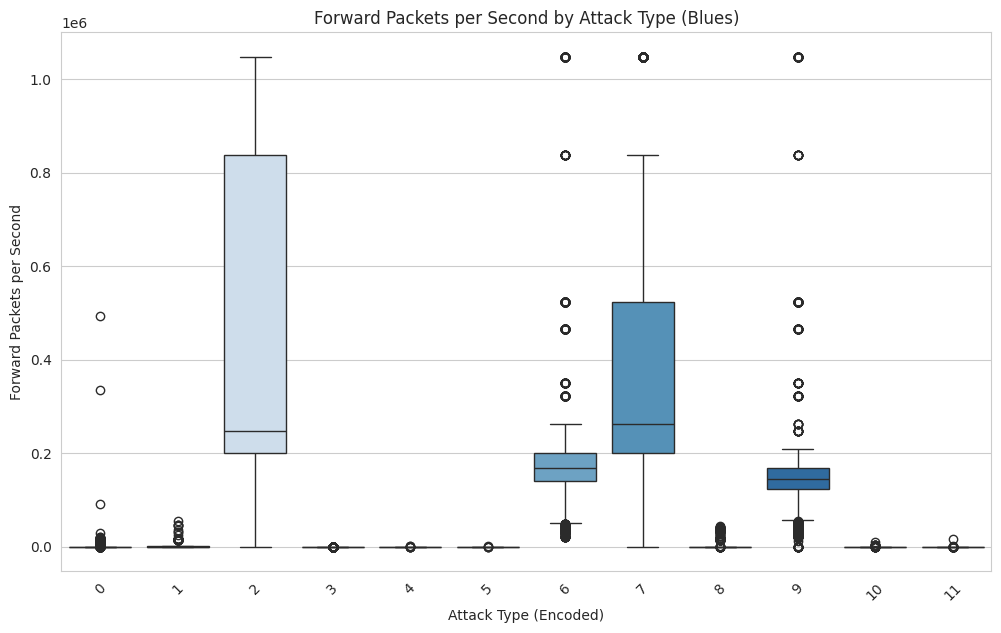

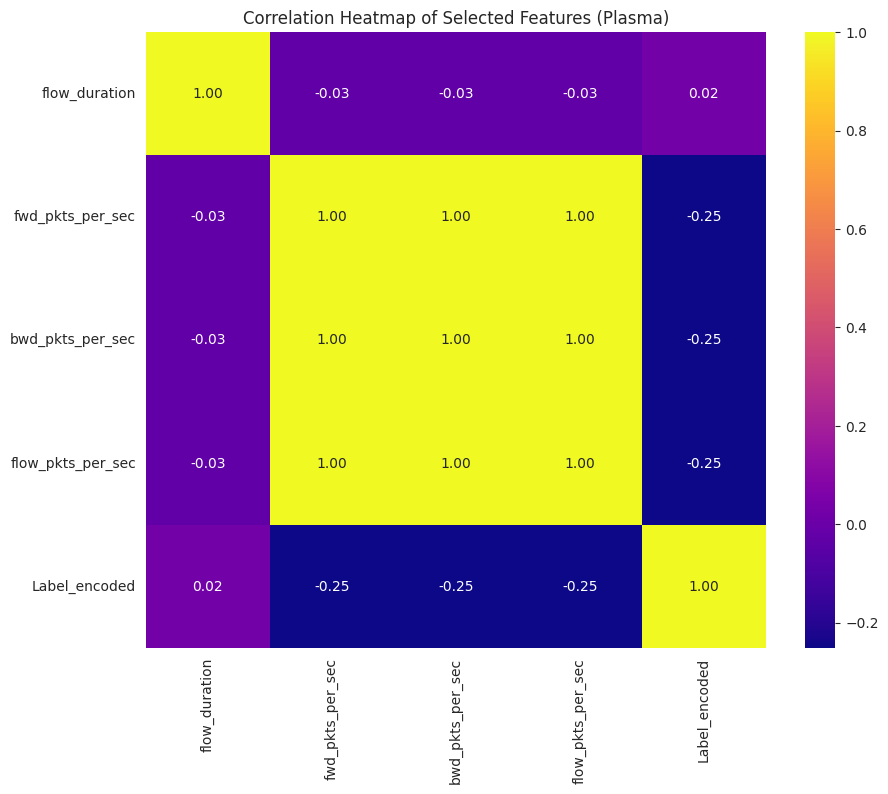

Analysis and Visualization Complete
Index(['no', 'id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration',
       'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot',
       'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec',
       'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot',
       'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot',
       'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count',
       'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count',
       'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count',
       'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count',
       'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot',
       'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min',
       'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg',
       'bwd_pkts_payload.std', 'flow_pkts_payload.min',
       'flow_pkts_paylo

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("RT_IOT2022.csv")

# Transform data
def transform_data(df):
    if 'Attack_type' in df.columns:
        df['Label_encoded'] = df['Attack_type'].astype('category').cat.codes
    return df

transformed_data = transform_data(data)

print("Transformed Dataset Sample")
print(transformed_data.head())

# Analyze data
def analyze_data(df):
    print("Starting Data Loading")
    if df.empty:
        print("DataFrame is empty")
        return

    print("Statistical Summary")
    print(df[['flow_duration', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec']].describe())

    print("\n--- Correlation Matrix (Top Numeric Features) ---")
    corr_matrix = df[['flow_duration', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'Label_encoded']].corr()
    print(corr_matrix)

    print("\n--- Generating Visualizations ---")
    sns.set_style("whitegrid")

    # Histogram
    plt.figure(figsize=(10, 6))
    sns.histplot(df['flow_duration'], bins=50, kde=True, color=sns.color_palette("viridis", 10)[5])
    plt.title('Distribution of Flow Duration (Viridis)')
    plt.xlabel('Flow Duration (seconds)')
    plt.ylabel('Frequency')
    plt.show()

    # Boxplot
    plt.figure(figsize=(12, 7))
    sns.boxplot(x='Label_encoded', y='fwd_pkts_per_sec', data=df, palette="viridis")
    plt.title('Forward Packets per Second by Attack Type (Viridis)')
    plt.xlabel('Attack Type (Encoded)')
    plt.ylabel('Forward Packets per Second')
    plt.xticks(rotation=45)
    plt.show()

    # Boxplot
    plt.figure(figsize=(12, 7))
    sns.boxplot(x='Label_encoded', y='fwd_pkts_per_sec', data=df, palette="plasma")
    plt.title('Forward Packets per Second by Attack Type (Plasma)')
    plt.xlabel('Attack Type (Encoded)')
    plt.ylabel('Forward Packets per Second')
    plt.xticks(rotation=45)
    plt.show()

    # Boxplot
    plt.figure(figsize=(12, 7))
    sns.boxplot(x='Label_encoded', y='fwd_pkts_per_sec', data=df, palette="Blues")
    plt.title('Forward Packets per Second by Attack Type (Blues)')
    plt.xlabel('Attack Type (Encoded)')
    plt.ylabel('Forward Packets per Second')
    plt.xticks(rotation=45)
    plt.show()

    # Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap="plasma", fmt=".2f")
    plt.title('Correlation Heatmap of Selected Features (Plasma)')
    plt.show()

    print("Analysis and Visualization Complete")
    print(df.columns)

# Run analysis
analyze_data(transformed_data)

#**Conclusion/Analysis**
In this quiz, I used the previous activities as my guide to structure the analysis clearly. I began by extracting the dataset, checking its shape, and previewing the first few rows to understand the features. Then I transformed the data by encoding the attack types into numeric labels, which allowed me to run statistical summaries and correlation checks. I followed this with visualizations such as histograms, boxplots, and heatmaps to make patterns easier to see. For the colors, I chose palettes like viridis, plasma, and Blues because they highlight differences between categories, even though the gradients can feel intense or hurt to see. That sharpness is intentional it forces the eye to notice contrasts and relationships that might otherwise be overlooked. By the end, the load phase confirmed the datasets structure and ensured the analysis was complete.